In [ ]:
# ============================================
# IRIS FLOWER CLASSIFICATION
# CodSoft Data Science Internship - Task 3
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Iris dataset directly sklearn se
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print(" All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [ ]:
# ============================================
# STEP 2 - DATA LOADING & EXPLORATION
# ============================================

# Iris dataset load karo
iris = load_iris()

# DataFrame banao
df = pd.DataFrame(
    iris.data, 
    columns=iris.feature_names
)

# Target column add karo
df['Species'] = iris.target
df['Species_Name'] = df['Species'].map({
    0: 'Setosa', 
    1: 'Versicolor', 
    2: 'Virginica'
})

print(" Dataset Loaded Successfully!")
print(f" Shape: {df.shape}")
print(f"\n First 5 Rows:")
print(df.head())

print(f"\n Species Count:")
print(df['Species_Name'].value_counts())

print(f"\n Missing Values:")
print(df.isnull().sum())

print(f"\n Basic Statistics:")
print(df.describe())

✅ Dataset Loaded Successfully!
📊 Shape: (150, 6)

📋 First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species Species_Name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

📊 Species Count:
Species_Name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

🔍 Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
Species_Name         0
dtype: int64

📊 Basic Statistics:
    

Text(0.5, 1.0, 'Feature Distribution')

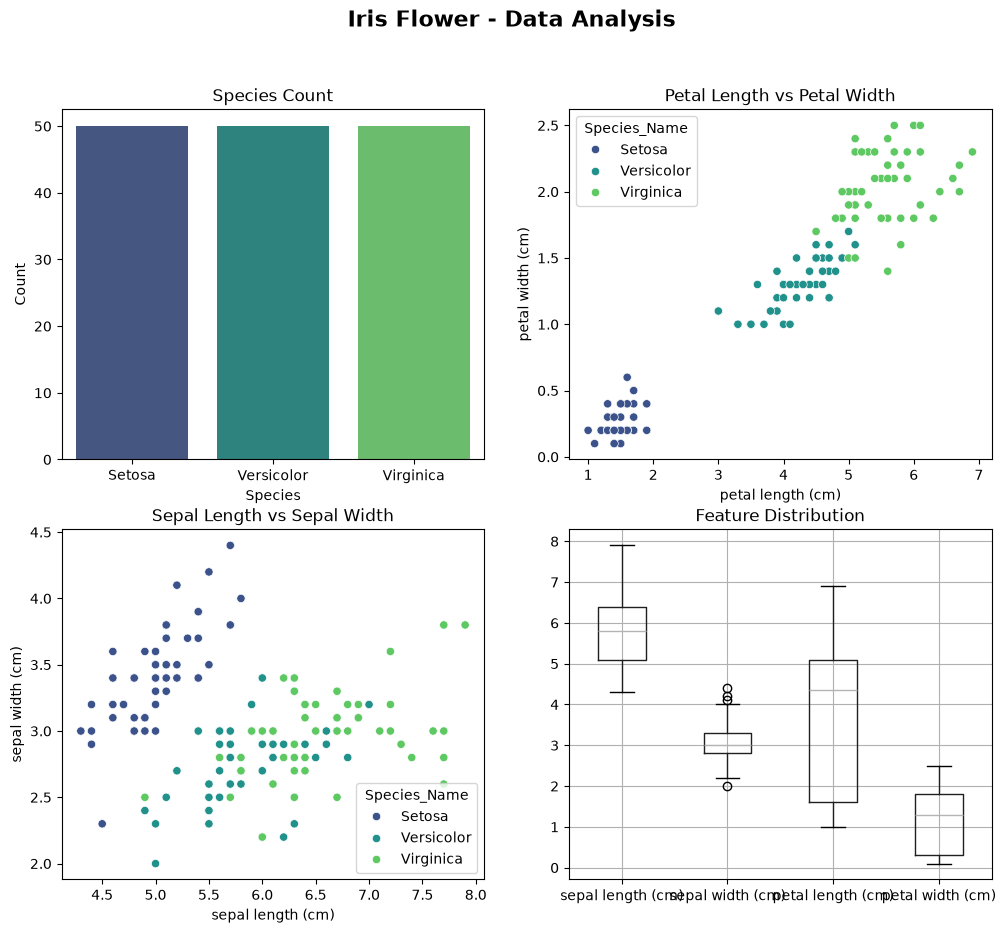

In [3]:
# ============================================
# STEP 3 - DATA VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Iris Flower - Data Analysis', 
             fontsize=16, fontweight='bold')

# Graph 1 - Species Count
sns.countplot(x='Species_Name', data=df, 
              palette='viridis', ax=axes[0,0],
              hue='Species_Name', legend=False)
axes[0,0].set_title('Species Count')
axes[0,0].set_xlabel('Species')
axes[0,0].set_ylabel('Count')

# Graph 2 - Petal Length vs Petal Width
sns.scatterplot(x='petal length (cm)', 
                y='petal width (cm)',
                hue='Species_Name', 
                data=df, palette='viridis',
                ax=axes[0,1])
axes[0,1].set_title('Petal Length vs Petal Width')

# Graph 3 - Sepal Length vs Sepal Width
sns.scatterplot(x='sepal length (cm)', 
                y='sepal width (cm)',
                hue='Species_Name', 
                data=df, palette='viridis',
                ax=axes[1,0])
axes[1,0].set_title('Sepal Length vs Sepal Width')

# Graph 4 - Box Plot
df.boxplot(column=['sepal length (cm)', 
                   'sepal width (cm)',
                   'petal length (cm)', 
                   'petal width (cm)'],
           ax=axes[1,1])
axes[1,1].set_title('Feature Distribution')

In [ ]:
# ============================================
# STEP 4 - MODEL BUILDING
# ============================================

# Features aur Target
X = df.drop(columns=['Species', 'Species_Name'])
y = df['Species']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f" Training Set: {X_train.shape}")
print(f" Testing Set:  {X_test.shape}")

# MODEL 1 - Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# MODEL 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# MODEL 3 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Comparison
print("\n" + "=" * 45)
print(" MODEL COMPARISON")
print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {lr_acc*100:>9.2f}%")
print(f"{'Decision Tree':<25} {dt_acc*100:>9.2f}%")
print(f"{'Random Forest':<25} {rf_acc*100:>9.2f}%")

accs = {'Logistic Regression': lr_acc, 
        'Decision Tree': dt_acc, 
        'Random Forest': rf_acc}
winner = max(accs, key=accs.get)
print(f"\n Winner: {winner}")

✅ Training Set: (120, 4)
✅ Testing Set:  (30, 4)

🏆 MODEL COMPARISON
Model                       Accuracy
---------------------------------------------
Logistic Regression          100.00%
Decision Tree                100.00%
Random Forest                100.00%

🥇 Winner: Logistic Regression


📊 CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



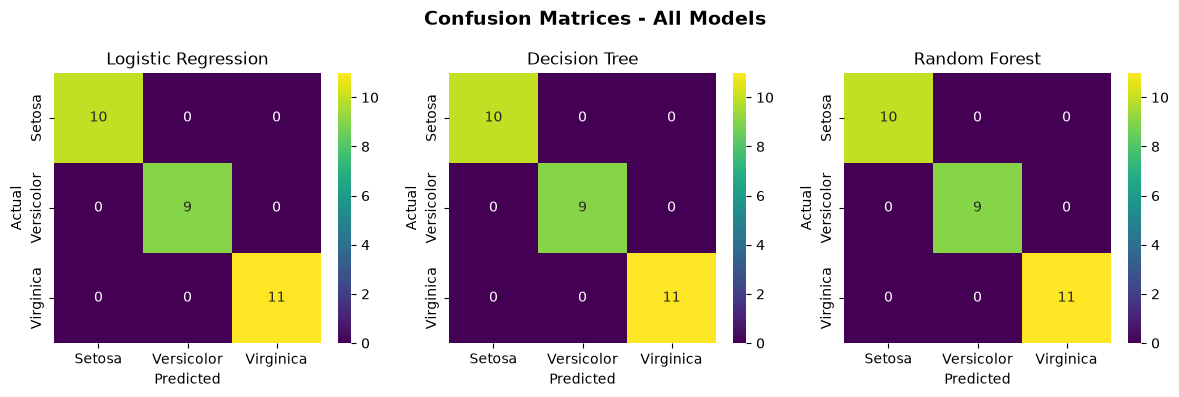


🌸 IRIS FLOWER PREDICTOR

Flower 1: Small petals  (1.4cm)
Predicted Species: 🌸 Setosa
--------------------------------------------------
Flower 2: Medium petals (4.5cm)
Predicted Species: 🌺 Versicolor
--------------------------------------------------
Flower 3: Large petals  (6.1cm)
Predicted Species: 🌼 Virginica
--------------------------------------------------


In [ ]:
# ============================================
# STEP 5 - EVALUATION + PREDICTION
# ============================================

species_names = ['Setosa', 'Versicolor', 'Virginica']

# Classification Report
print("=" * 50)
print(" CLASSIFICATION REPORT - RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_pred, 
      target_names=species_names))

# Confusion Matrix
plt.figure(figsize=(12, 4))

# Plot 3 confusion matrices
models = [('Logistic Regression', lr_pred), 
          ('Decision Tree', dt_pred),
          ('Random Forest', rf_pred)]

for i, (name, pred) in enumerate(models):
    plt.subplot(1, 3, i+1)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', 
                cmap='viridis',
                xticklabels=species_names,
                yticklabels=species_names)
    plt.title(f'{name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Real Prediction
print("\n IRIS FLOWER PREDICTOR")
print("=" * 50)

new_flowers = pd.DataFrame({
    'sepal length (cm)': [5.1, 6.5, 7.2],
    'sepal width (cm)':  [3.5, 2.8, 3.0],
    'petal length (cm)': [1.4, 4.5, 6.1],
    'petal width (cm)':  [0.2, 1.5, 2.3]
})

flowers_info = [
    "Flower 1: Small petals  (1.4cm)",
    "Flower 2: Medium petals (4.5cm)",
    "Flower 3: Large petals  (6.1cm)"
]

predictions = rf.predict(new_flowers)

print()
for info, pred in zip(flowers_info, predictions):
    species = species_names[pred]
    emoji = "🌸" if pred==0 else "🌺" if pred==1 else "🌼"
    print(f"{info}")
    print(f"Predicted Species: {emoji} {species}")
    print("-" * 50)